# Основы статистики и A/B-тестирования

https://practicum.yandex.ru/profile/statistics-basic/



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import scipy.stats as ss # ttest_ind, mannwhitneyu
# from statsmodels.stats.weightstats import ztest
from statsmodels.stats.power import TTestIndPower, tt_ind_solve_power

In [4]:
alpha = 1 - 0.05/2
ss.norm.ppf(1-alpha).round(3),  ss.norm.ppf(alpha).round(3)

(-1.96, 1.96)

In [16]:
print(f"z-score=1.64, alpha=0.1: {ss.norm.cdf(-1.645).round(3), ss.norm.cdf(1.645).round(3)}")
print(f"z-score=1.96, alpha=0.05: {ss.norm.cdf(-1.960).round(3), ss.norm.cdf(1.960).round(3)}")
print(f"z-score=2.58, alpha=0.01: {ss.norm.cdf(-2.576).round(3), ss.norm.cdf(2.576).round(3)}")

z-score=1.64, alpha=0.1: (0.05, 0.95)
z-score=1.96, alpha=0.05: (0.025, 0.975)
z-score=2.58, alpha=0.01: (0.005, 0.995)


# Статистические тесты
## Стандартная ошибка среднего

In [5]:
# среднее кол-во пятен жирафа
data = np.array([220, 250, 230, 245, 255])
data.mean()

240.0

In [7]:
mean = 245
std = 50

general = np.random.normal(loc=mean, scale=std, size=1000)

In [46]:
sample = pd.Series(general).sample(100).values.mean()
sample_mean = sample.mean()
sample_std = sample.std()

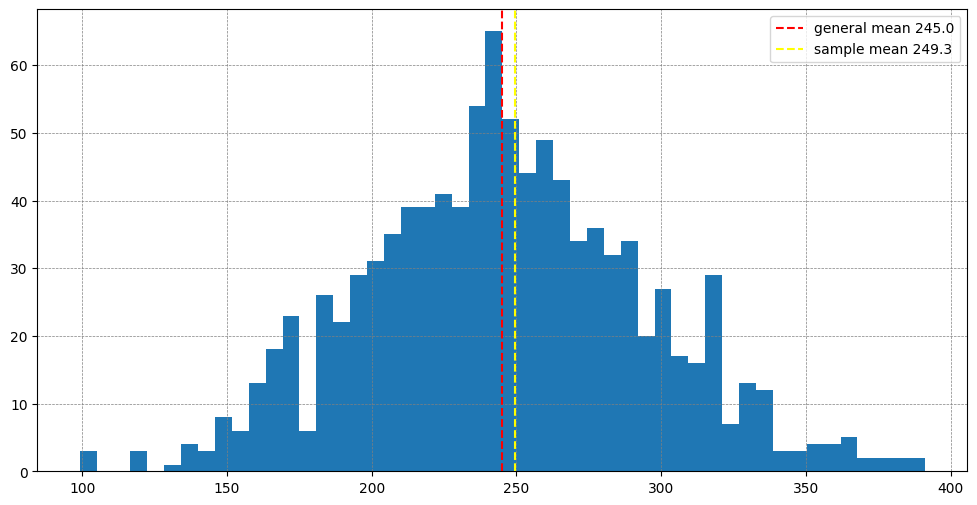

In [50]:
plt.figure(figsize = (12, 6))
plt.hist(general, bins=50)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(mean, color='red', linestyle='--', label=f"general mean {mean:.1f}")
plt.axvline(sample_mean, color='yellow', linestyle='--', label=f"sample mean {sample_mean:.1f}")
plt.legend()
plt.show()

In [82]:
l = np.array([240, 260, 250, 245, 255, 243, 257, 248, 252, 240])
print(
    'var: %.2f, std: %.2f' % (l.var(ddof=1), l.std(ddof=1))
)

var: 49.56, std: 7.04


### ЦПТ

In [107]:
mean = 245
std = 54.45
n = 100
itterations = 1000

general = np.random.normal(loc=mean, scale=std, size=10000)

sample_list = []
for _ in range(itterations):
    sample_list.append(pd.Series(general).sample(n).values.mean())

In [108]:
np.array(sample_list).mean()

245.34622919298516

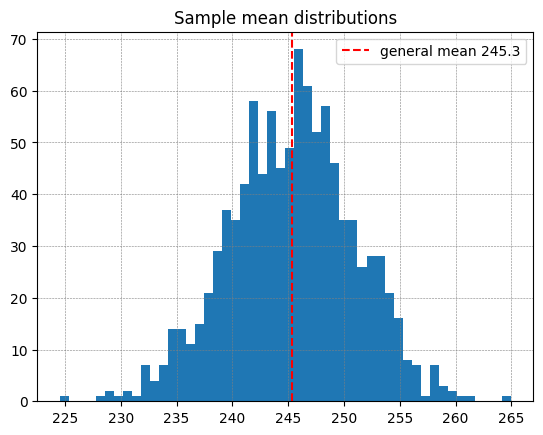

In [116]:
plt.hist(sample_list, bins=50)
plt.grid(color='gray', linestyle='--', linewidth=0.4)
plt.axvline(np.array(sample_list).mean(), color='red', linestyle='--', label=f"general mean {np.array(sample_list).mean():.1f}")
plt.title(label='Sample mean distributions')
plt.legend()
plt.show()

### Стандартная ошибка среднего

In [119]:
se = std / n ** 0.5
se

5.445

## Статистические гипотезы (z критерий)

`Z ~ N(Mu, SD)`

In [321]:
z_score = 1.96
alpha = 0.05
print('%.3f' % ss.norm.pdf(z_score)) # вычисляет высоту плотности (но НЕ вероятность).
print('%.3f' % ss.norm.cdf(z_score)) # вычисляет накопленную вероятность
print('%.3f' % ss.norm.ppf(1-alpha/2)) # Принимает накопленную вероятность и возвращает z-значение

0.058
0.975
1.960


In [126]:
sample_mean = 258
sample_std = 50
sample_size = 100

se = sample_std / sample_size ** 0.5

hypothesis_mean = 250

In [128]:
se

5.0

In [129]:
z = (sample_mean - hypothesis_mean) / se
z

1.6

In [139]:
sample_mean-se*1.96, sample_mean+se*1.96,

(248.2, 267.8)

In [136]:
# z to probability
ss.norm.cdf(z)

0.945200708300442

In [135]:
# probability to z
ss.norm.ppf(0.975)

1.959963984540054

### задача

Поговорим о вечной проблеме — о дорогах. По норме в асфальте должно быть 700 грамм щебня на каждый килограмм. Комиссия проводит измерения в новом асфальте, чтобы не пришлось перекладывать заново в следующем ноябре. Проверяющие берут пробу на 25 разных участках и замеряют количество щебня.

Вот какие данные используются в исследовании:   
Предполагаемое среднее значение генеральной совокупности: 700   
Стандартное отклонение генеральной совокупности: 80   
Среднее значение по выборке: 660   
Размер выборки: 25.

H0 = 700   
H1 != 700

In [281]:
def between(x:[int|float], a, b) -> bool:
    """ between(10, 8, 12) -> (10 >= 8 and 10 <= 12) -> True """
    return x >= a and x <= b

In [282]:
between(10, 8, 12)

True

In [140]:
mean = 700
std = 80

X = 660
n = 25

alpha = 0.05

In [141]:
se = std / n ** 0.5
z = (X - mean) / se

f"se:{se:.3f}, z:{z:.3f}"

'se:16.000, z:-2.500'

In [147]:
ss.norm.ppf(1-alpha/2)

1.959963984540054

In [163]:
print(
    f"X {X} between {mean-se*1.96, mean+se*1.96} - {between(X, mean-se*1.96, mean+se*1.96)}"
     )

X 660 between (668.64, 731.36) - False


In [170]:
print(f"pval: {ss.norm.cdf(z)*2:.4f}")
print(f"pval < alpha: {ss.norm.cdf(z)*2 < alpha}")

if ss.norm.cdf(z)*2 < alpha:
    print('reject H0')
else:
    print("can't reject H0")

pval: 0.0124
pval < alpha: True
reject H0


## p-value

P-value - вероятность получить определённое или ещё более экстремальное значение статистического критерия при условии, что нулевая гипотеза верна.

In [2]:
def z_test_two_sides(general_mean, general_std, sample_mean, sample_size, alpha=0.05, _round=3)->dict:
    """ return dict: z_score, p_value, H0 reject?, se  """
    se = general_std / sample_size ** 0.5
    z_score = (sample_mean - general_mean) / se
    p_value = (1-ss.norm.cdf(abs(z_score))) * 2
    return {'z_score':z_score, 'p_value':round(p_value, _round), 'H0 reject?':p_value<alpha, 'se':se}

In [65]:
# Упражнение 1
# Вернёмся к исследованию масс животных. В норме самец императорского пингвина весит 40 кг. 

p_mean = 40
p_std = 10

x_mean = 36
n = 64

# Сформулируем гипотезы: Η0: μ = 40, H1: μ != 40.
alpha = 0.05

# Рассчитайте значение z-статистики, подставьте его в калькулятор, получите р-value и сделайте вывод о том, есть ли отклонение от стандарта.
print(
    z_test_two_sides(p_mean, p_std, x_mean, n)
)

{'z_score': -3.2, 'p_value': 0.001, 'H0 reject?': True, 'se': 1.25}


In [10]:
se = p_std / n **0.5
z_score = ((x_mean-p_mean)/se)
p_val = (1-ss.norm.cdf(abs(z_score))) * 2
se, z_score, p_val

(1.25, -3.2)

In [197]:
# задачка 2
z_test_two_sides(general_mean=53, general_std=17, sample_mean=48, sample_size=100, alpha=0.05)

{'z_score': -2.9411764705882355,
 'p_value': 0.003,
 'H0 reject?': True,
 'se': 1.7}

### ошибка первого рода

`Ошибка первого рода`, а - это ситуация, когда исследователь отвергает нулевую гипотезу, хотя она на самом деле верна.   
`Ошибка второго рода`, В - это ситуация, когда исследователь не отвергает нулевую гипотезу, хотя верна альтернативная.   
`Мощность статистического теста`, 1 - В - это вероятность правильно отклонить нулевую гипотезу, когда она действительно неверна.   

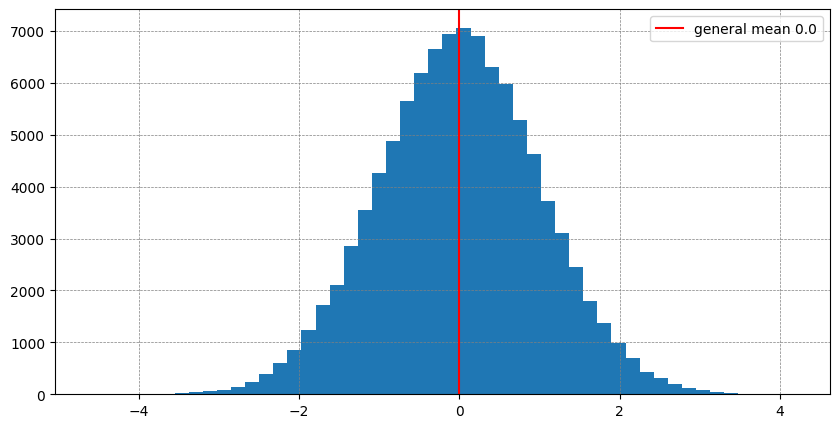

In [37]:
mean = 0
sd = 1
size = 100_000
population = ss.norm.rvs(loc=mean, scale=sd, size=size)

plt.figure(figsize =  (10, 5))
plt.hist(population, bins=50)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(mean, color='red', linestyle='-', label=f"general mean {mean:.1f}")
plt.legend()
plt.show()

In [38]:
sample_size = 50
sample = pd.Series(population).sample(sample_size)
sample_mean = np.array(sample).mean()
alpha = 0.05

In [54]:
samples_mean = []
for _ in tqdm(range(10_000)):
    sample = pd.Series(population).sample(sample_size)
    sample_mean = np.array(sample).mean()
    samples_mean.append(sample_mean)

samples_mean = np.array(samples_mean)

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:19<00:00, 510.31it/s]


In [76]:
? z_test_two_sides

Signature:
 z_test_two_sides(
    general_mean,
    general_std,
    sample_mean,
    sample_size,
    alpha=0.05,
    _round=3,
) -> dict
Docstring: return dict:z_score, p_value, H0 reject?, se  
File:      c:\users\ilyao\appdata\local\temp\ipykernel_15816\3450732639.py
Type:      function

In [114]:
# degree of freedom in numpy
# (((np.array([5, 10, 8, 12]) - 8.75) ** 2).sum() / 3) ** 0.5
# np.array([5, 10, 8, 12]).std(ddof=1)

In [93]:
pd.Series(samples_mean).map(lambda x: z_test_two_sides(mean, sd, x, sample_size)['se']).mean()

0.14142135623730948

In [86]:
samples_zscore = pd.Series(samples_mean).map(lambda x: z_test_two_sides(mean, sd, x, sample_size)['z_score'])
samples_pval = pd.Series(samples_mean).map(lambda x: z_test_two_sides(mean, sd, x, sample_size)['p_value'])

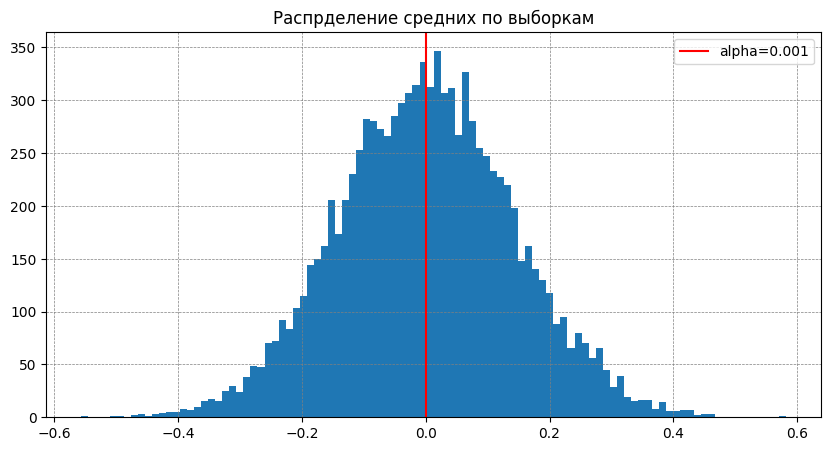

In [120]:
plt.figure(figsize = (10, 5))
plt.hist(samples_mean, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(samples_mean.mean(), color='red', linestyle='-', label=f"alpha={samples_mean.mean():.3f}")
plt.title("Распределение средних по выборкам")
plt.legend()
plt.show()

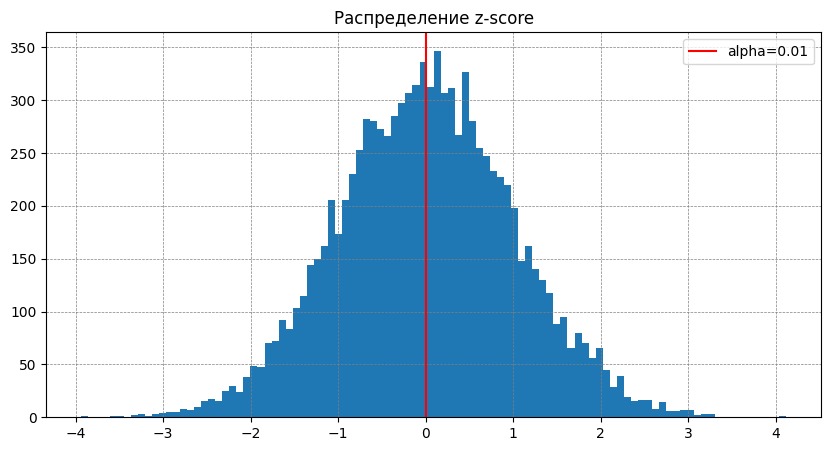

In [144]:
plt.figure(figsize = (10, 5))
plt.hist(samples_zscore, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(samples_zscore.mean(), color='red', linestyle='-', label=f"mean={samples_zscore.mean():.2f}")
plt.title("Распределение z-score")
plt.legend()
plt.show()

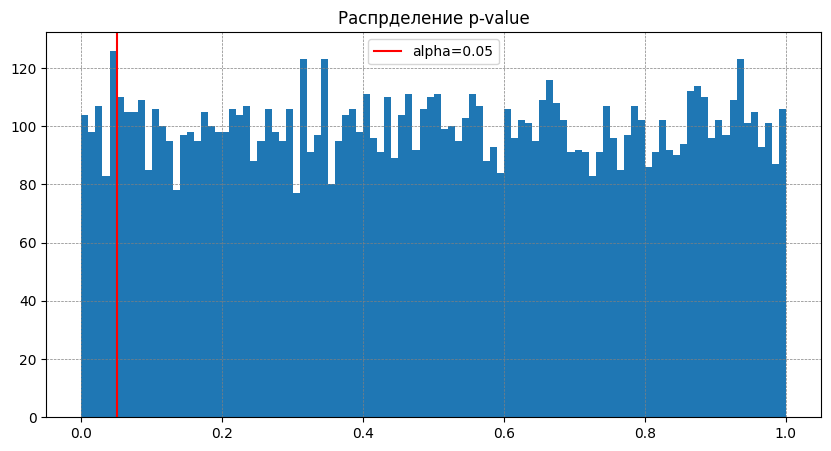

In [85]:
plt.figure(figsize = (10, 5))
plt.hist(samples_pval, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(alpha, color='red', linestyle='-', label=f"alpha={alpha:.2f}")
plt.title("Распрделение p-value")
plt.legend()
plt.show()

In [151]:
# first type error
print('Эффекта нет. Какой процент ложноположительных изменений:', (samples_pval < alpha).mean())

Эффекта нет. Какой процент ложноположительных изменений: 0.0518


### Вывод по p-value и О1Р
Мы взяли группу - "популяция" с параметрами: нормальное распрделение, среднее=0, СД=1, размером 1млн.   
После этого взяли 10 тыс. выборок по 50 штук. В каждой выборке считатали среднее и получили лист со средними из выборок.    
После чего все эти среднии выборок мы проверили z-тестом и получили статистику и p-значение.    
Получили 10 тыс. разниц средних между выборкаой и ГС, по которой мы видим, что отклонения распрделены так же нормально, так же нормальное распрделение имеет z-значение- по сути это просто стандартизированные значения.

И самый важный момент тут взаимосвязь p-value и О1Р. Так как выборки точно взяты из ГС, значения выборки распрделены нормально, мы получаем равномерное распрделение наших "ошибок" от 0 до 1. И самое главное что доля наших ошибок, так же равно альфе которая была выбрана, например есть взять alpha=0.05, то у нас она так же 0.05.   
То есть учитывая что выборки точно равны, у нас все равно 5% значений выходят за предел нормального распрделения и мы говорим что эффексть есть, то ест совершаем О1Р.

### О2Р и Мощность. Сдвигаем выборку на 40%

Вторая часть симуляции, нужна нам чтобы лучше понимать, а что будет, если выборка окажется не из той же ГС, а с каким то эффектом (в нашем случае +40%).   
И сразу видим, что средняя разница между выборкой и ГС уже не равна нулю.

Перед выводом в прошлом блоке, мы проверяли точно alpha и реальных О1Р, они совпадала. Интересно то, что в этом блоке, когда мы точно знаем эффект, сама проверка не будет меняться, но поменяется число, теперь там будет не 0,05% ошибок первого рода, а будет отражена мощность нашего теста с выбранными параметрами, потому что теперь мы фиксируем стат. значемые изменения и получаем тем самым 80%.   
Повлиять в данном случае на мощност мы можем через 2 параметра: 
* `Размер эффекта (MDE)` - В данном случае я подобпрал руками такой эффект чтобы мощность была около 80%, при этом если поставить эффект +500%, то даже с небольшой группой наша мощность станет равна =1, то есть мы всегда будем детектить эффект! 
* `Обьем выборки` - еще одна переменная, на которую мы можем влиять, чтобы увлечить мощность, то есть мы можем понизить эффект до +5%, но тогда мы должны сущесвенно увеличить размер выборки, чтобы снова гарантировать мощность в 80%.

In [181]:
sample_size = 50
samples_mean_effect = []

for _ in tqdm(range(10_000)):
    sample = pd.Series(population).sample(sample_size).values
    sample_mean = sample.mean() + 0.40 # добавляем эффект в 40%
    samples_mean_effect.append(sample_mean)

samples_mean_effect = np.array(samples_mean_effect)

samples_effect_zscore = pd.Series(samples_mean_effect).map(lambda x: z_test_two_sides(mean, sd, x, sample_size)['z_score'])
samples_effect_pval = pd.Series(samples_mean_effect).map(lambda x: z_test_two_sides(mean, sd, x, sample_size)['p_value'])

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:19<00:00, 512.88it/s]


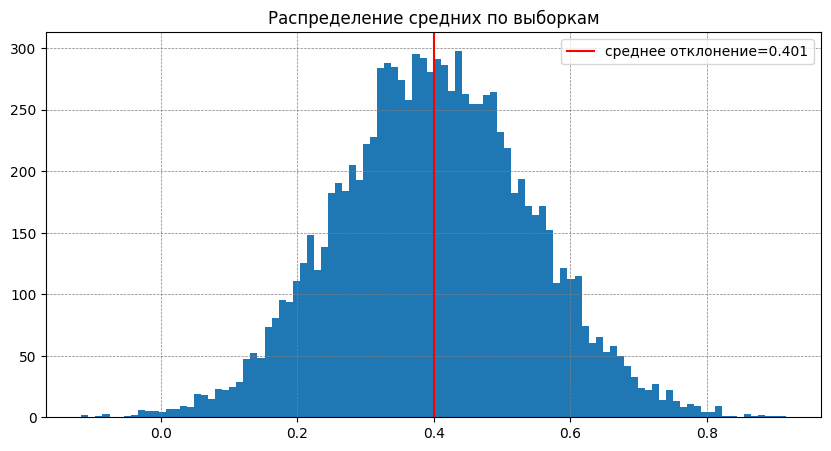

In [182]:
plt.figure(figsize = (10, 5))
plt.hist(samples_mean_effect, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(samples_mean_effect.mean(), color='red', linestyle='-', label=f"среднее отклонение={samples_mean_effect.mean():.3f}")
plt.title("Распределение средних по выборкам")
plt.legend()
plt.show()

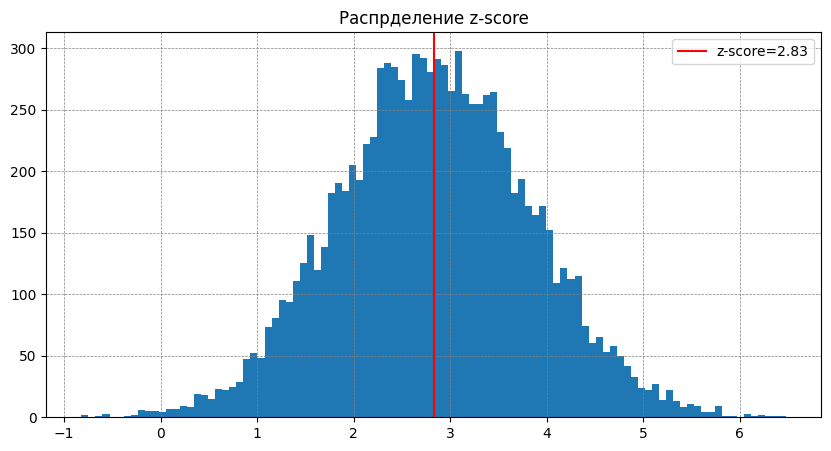

In [183]:
plt.figure(figsize = (10, 5))
plt.hist(samples_effect_zscore, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(samples_effect_zscore.mean(), color='red', linestyle='-', label=f"z-score={samples_effect_zscore.mean():.2f}")
plt.title("Распрделение z-score")
plt.legend()
plt.show()

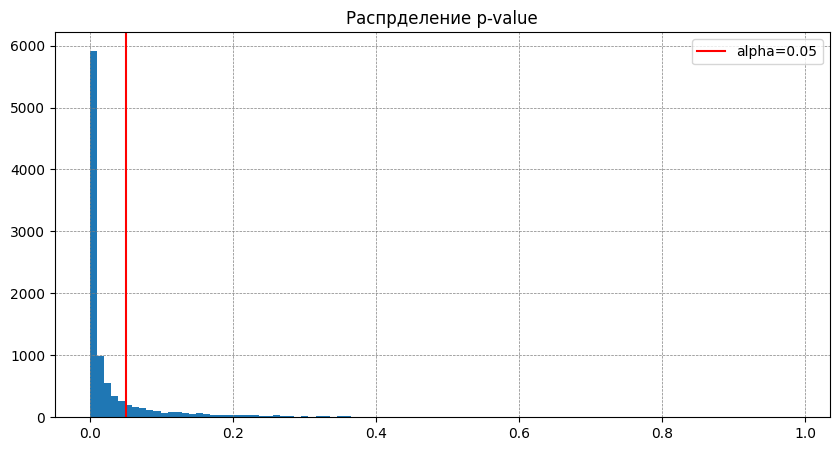

In [184]:
plt.figure(figsize = (10, 5))
plt.hist(samples_effect_pval, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(alpha, color='red', linestyle='-', label=f"alpha={alpha:.2f}")
plt.title("Распрделение p-value")
plt.legend()
plt.show()

In [185]:
# second type error and power of test
print('Эффект есть. Какая мощность у нашего теста, то есть когда мы обнаружили эффект :', (samples_effect_pval < alpha).mean())

Эффект есть. Какая мощность у нашего теста, то есть когда мы обнаружили эффект : 0.8071


In [195]:
se_se = samples_effect_pval.std()/samples_effect_pval.count()**0.5
# строим ДИ (доверительный интервал) для значения мощности 
(samples_effect_pval < alpha).mean() - se_se*1.96, (samples_effect_pval < alpha).mean() + se_se*1.96

(0.8049996375447577, 0.8092003624552424)

## T-тест и распределение Стьюдента

Алгоритм проведения Т-теста:
1. Формулируем Н0, H1
2. Выбираем `аlpha`
3. Считаем выборочное среднее
4. Считаем выборочное стандартное отклонение
5. Считаем `t-статистику`
6. Считаем количество степеней свободы по формуле:   
`df = n-1`, где `n` - количество наблюдений в выборке
7. Считаем `p-value`
8. Сравниваем `p-value` с уровнем значимости:

* Если `p-value` меньше уровня значимости, принимаем решение, что
надо отклонить нулевую гипотезу.
* Если `p-value` больше уровня значимости, то оснований отклонять
нулевую гипотезу нет.

### Оценка стандартное ошибки (ese) 

In [3]:
def t_test_two_sides(hypotesis_mean, sample_mean, sample_std, sample_size, alpha=0.05, precision=3)->dict:
    """ return dict: t_stat, p_value, reject_H0, ese  """
    ese = sample_std / sample_size ** 0.5
    df = sample_size-1
    t_stat = (sample_mean - hypotesis_mean) / ese
    p_value = (1 - ss.t.cdf(abs(t_stat), df)) * 2
    return {'t_stat':round(t_stat, precision), 'p_value':round(p_value, precision), 'reject_H0':p_value<alpha, 'ese':round(ese, precision)}

In [274]:
mean = 250
sd = 54.45
size = 50

population_zoo = ss.norm.rvs(loc=mean, scale=sd, size=size)

In [275]:
population_zoo.std(ddof=1)

56.593716193929325

In [285]:
se = sd/size**0.5
ese = population_zoo.std(ddof=1)/size**0.5

f"{se=:.3f} {ese=:.3f}"

'se=7.700 ese=8.004'

### Когда появляется t-статистика

In [291]:
# H0: Mu = 8 H1: Mu != 8
Mu = 8

sample_x = 8.2
sample_sd = 0.6
samplse_size = 25

alpha = 0.05
ese = 0.6 / samplse_size ** 0.5
df = samplse_size - 1

t_stat = (sample_x - Mu) / ese

In [292]:
t_critical = ss.t.ppf(1 - alpha/2, df)  # Двухсторонний тест
print(f"Критическое значение T: ±{t_critical}")

Критическое значение T: ±2.0638985616280205


In [297]:
# Двусторонний p-value
p_value = (1 - ss.t.cdf(abs(t_stat), df)) * 2
# ss.t.sf(abs(t_stat), df) == (1 - ss.t.cdf(abs(t_stat), df))
print(f"P-value: {p_value}")
print(f"Reject H0?: {p_value < alpha}")

P-value: 0.10858012302472408
Reject H0?: False


In [4]:
t_test_two_sides(hypotesis_mean=50, sample_mean=50.2, sample_std=0.5, sample_size=40)

{'t_stat': 2.53, 'p_value': 0.016, 'reject_H0': True, 'ese': 0.079}

## Сравнение групп

### Двухвыборочный T-тест

ese = (var1/n1 + var2/n2) ** 0.5
t_stat = (x1 - x2) / ese

Степени свободны:   
* **Если группы равны**: `df = ((n-1) * (var1+var2)**2) / (var1**4 + var2**4)`
* **Если группы не равны**: df = \   
```python
ese1_sq = (s1 ** 2) / n1
ese2_sq = (s2 ** 2) / n2
numerator = (ese1_sq + ese2_sq) ** 2
denominator = (ese1_sq ** 2) / (n1 - 1) + (ese2_sq ** 2) / (n2 - 1)
df = numerator / denominator
```

In [363]:
def t_test_two_group(x1_mean, x1_std, x1_n, x2_mean, x2_std, x2_n, alpha=0.05, precision=3)->dict:
    """ return dict: t_stat, p_value, reject_H0, ese, df  """
    ese = (x1_std**2 / x1_n + x2_std**2 / x2_n)**0.5
    t_stat = (x1_mean - x2_mean) / ese
    if x1_n == x2_n:
        df = ((x1_n-1) * (x1_std**2 + x2_std**2)**2) / (x1_std**4 + x2_std**4)
    else:
        numerator = (x1_std**2/x1_n + x2_std**2/x2_n) ** 2
        denominator = ((x1_std**2/x1_n) ** 2) / (x1_n - 1) + ((x2_std**2/x2_n) ** 2) / (x2_n - 1)
        df = numerator / denominator
    p_value = (1 - ss.t.cdf(abs(t_stat), df)) * 2

    return {'t_stat':round(t_stat, precision), 'p_value':round(p_value, precision), 'reject_H0':p_value<alpha, 'ese':round(ese, precision), 'df':round(df, precision)}

In [342]:
nort_giraffe = {'mean':203, 'std':35, 'n':300}
south_giraffe = {'mean':198, 'std':33, 'n':300}

ese = (nort_giraffe['std']**2 / nort_giraffe['n'] + south_giraffe['std']**2 / south_giraffe['n'])**0.5
t_stat = (nort_giraffe['mean'] - south_giraffe['mean']) / ese
df = ((nort_giraffe['n']-1) * (nort_giraffe['std']**2 + south_giraffe['std']**2)**2) / (nort_giraffe['std']**4 + south_giraffe['std']**4)
p_value = (1 - ss.t.cdf(abs(t_stat), df)) * 2

In [343]:
t_stat, ese, df, p_value

(1.8003168836597405, 2.777288845859093, 595.9414817390061, 0.07231617285809389)

In [364]:
t_test_two_group(203, 35, 300, 198, 33, 300)

{'t_stat': 1.8,
 'p_value': 0.072,
 'reject_H0': False,
 'ese': 2.777,
 'df': 595.941}

In [361]:
t_test_two_group(1240, 314, 600, 1203, 319, 600)

{'t_stat': 2.025, 'p_value': 0.043, 'reject_H0': True, 'ese': 18.274}

### Условия применимости T-теста

Теперь давайте поговорим о требованиях, при которых T-тест работает корректно. Их два: 
* независимость наблюдений
*  нормальность распределения выборочных средних.

Если проводить T-тест на выборках, у которых выборочные средние распределены не нормально, мощность теста снижается. Это означает, что мы будем реже отвергать нулевую гипотезу, когда она на самом деле должна быть отвергнута. А если распределение совсем не похоже на нормальное, то этом случае есть два варианта: использовать U-критерий Манна-Уитни или Бакетный тест.

#### Независимость наблюдений

#### Ненормальное распределение

In [5]:
giraffe_sample = np.random.exponential(50, 3000)

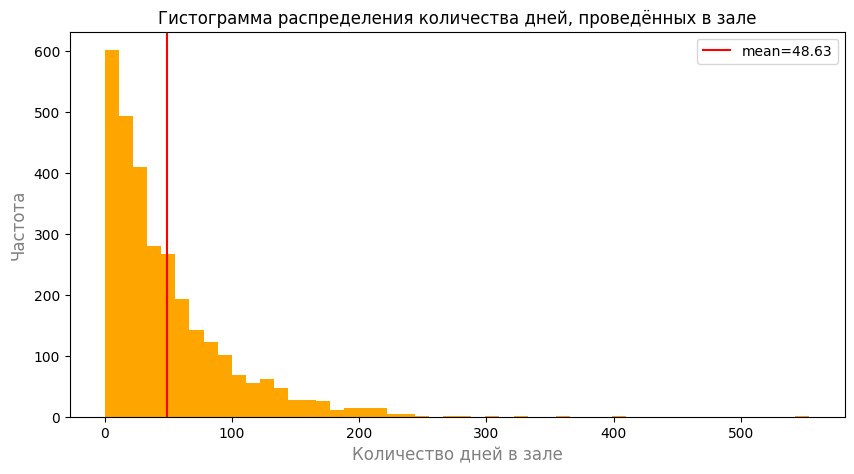

In [19]:
plt.figure(figsize = (10, 5))
plt.hist(giraffe_sample, bins=50, color='orange')
# plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(giraffe_sample.mean(), color='red', linestyle='-', label=f"mean={giraffe_sample.mean():.2f}")
plt.xlabel('Количество дней в зале', fontsize=12, color='grey')
plt.ylabel('Частота', fontsize=12, color='grey')
plt.title("Гистограмма распределения количества дней, проведённых в зале")
plt.legend()
plt.show()

#### U-критерий Манна-Уитни

In [ ]:
ss.mannwhitneyu()

#### Бакетный тест

In [57]:
np.random.shuffle(giraffe_sample)

In [58]:
np.array(np.split(giraffe_sample, 100)).shape

(100, 30)

In [59]:
backeted_giraffe_sample = np.array([x.mean() for x in np.split(giraffe_sample, 100)])

In [60]:
# H0=shape is normal
ss.shapiro(backeted_giraffe_sample)

ShapiroResult(statistic=0.9843349434644851, pvalue=0.2841083024574791)

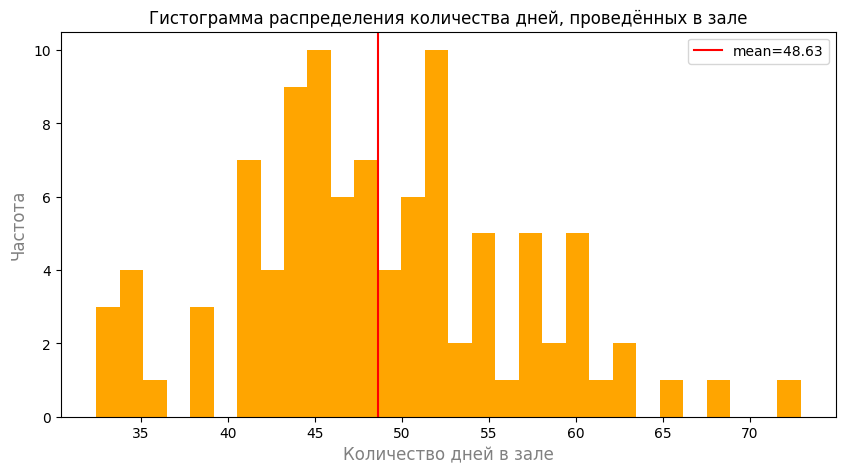

In [61]:
plt.figure(figsize = (10, 5))
plt.hist(backeted_giraffe_sample, bins=30, color='orange')
# plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(backeted_giraffe_sample.mean(), color='red', linestyle='-', label=f"mean={backeted_giraffe_sample.mean():.2f}")
plt.xlabel('Количество дней в зале', fontsize=12, color='grey')
plt.ylabel('Частота', fontsize=12, color='grey')
plt.title("Гистограмма распределения количества дней, проведённых в зале")
plt.legend()
plt.show()

### Тест для пропорций

In [161]:
def z_test_proportions(control_mean, treatment_mean, sample_size, alpha=0.05, _round=3)->dict:
    """ return dict: z_score, p_value, H0 reject?, se  """
    control_var = control_mean * (1-control_mean)
    treatment_var = treatment_mean * (1-treatment_mean)
    ese = (control_var / sample_size + treatment_var / sample_size) ** 0.5
    z_score = (treatment_mean - control_mean) / ese
    p_value = (1-ss.norm.cdf(abs(z_score))) * 2
    return {'z_score':z_score, 'p_value':round(p_value, _round), 'H0 reject?':p_value<alpha, 'ese':ese}

In [186]:
mean = 0.225
sample_size = 310
alpha = 0.05

samples_pval = []
for _ in tqdm(range(10_000)):
    control_sample_mean = np.random.binomial(1, mean, sample_size).mean()
    treatment_sample_mean = np.random.binomial(1, mean, sample_size).mean() + 0.1
    samples_pval.append(z_test_proportions(control_sample_mean, treatment_sample_mean, sample_size)['p_value'])

samples_pval = np.array(samples_pval)

100%|█████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 11416.30it/s]


In [187]:
print(f"""p-val: {(samples_pval < alpha).mean()}
CI: [{(samples_pval < alpha).mean() - samples_pval.std()/np.sqrt(sample_size)*1.96:.3f}, {(samples_pval < alpha).mean() + samples_pval.std()/np.sqrt(sample_size)*1.96:.3f}]:""")

p-val: 0.8071
CI: [0.796, 0.818]:


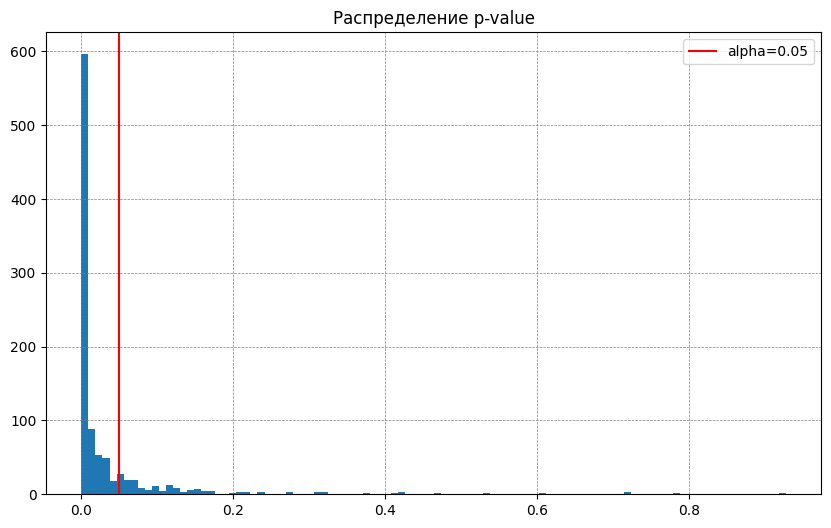

In [169]:
plt.figure(figsize = (10, 6))
plt.hist(samples_pval, bins=100)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axvline(alpha, color='red', linestyle='-', label=f"alpha={alpha:.2f}")
plt.title("Распределение p-value")
plt.legend()
plt.show()